In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # set BEFORE importing tensorflow

import logging
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)  # Python-side TF logs

import numpy as np
import matplotlib.pyplot as plt




2025-10-24 15:41:39.212061: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-24 15:41:39.212112: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-24 15:41:39.213636: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import voxelmorph as vxm
import neurite as ne

In [ ]:
npz = np.load('Data/tutorial_data.npz')
x_train = npz['train']
x_val = npz['validate']

# the 208 volumes are of size 160x192
vol_shape = x_train.shape[1:]
print('train shape:', x_train.shape)

train shape: (208, 192, 160)


In [4]:
nb_features = [
    [32, 32, 32, 32],         # encoder features
    [32, 32, 32, 32, 32, 16]  # decoder features
]
def vxm_data_generator(x_data, batch_size=32):
    """
    Generator that takes in data of size [N, H, W], and yields data for
    our custom vxm model. Note that we need to provide numpy data for each
    input, and each output.

    inputs:  moving [bs, H, W, 1], fixed image [bs, H, W, 1]
    outputs: moved image [bs, H, W, 1], zero-gradient [bs, H, W, 2]
    """

    # preliminary sizing
    vol_shape = x_data.shape[1:] # extract data shape
    ndims = len(vol_shape)

    # prepare a zero array the size of the deformation
    # we'll explain this below
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])

    while True:
        # prepare inputs:
        # images need to be of the size [batch_size, H, W, 1]
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]
        inputs = [moving_images, fixed_images]

        # prepare outputs (the 'true' moved image):
        # of course, we don't have this, but we know we want to compare
        # the resulting moved image with the fixed image.
        # we also wish to penalize the deformation field.
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

def plot_history(hist, loss_name='loss'):
    # Simple function to plot training history.
    plt.figure()
    plt.plot(hist.epoch, hist.history[loss_name], '.-')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()

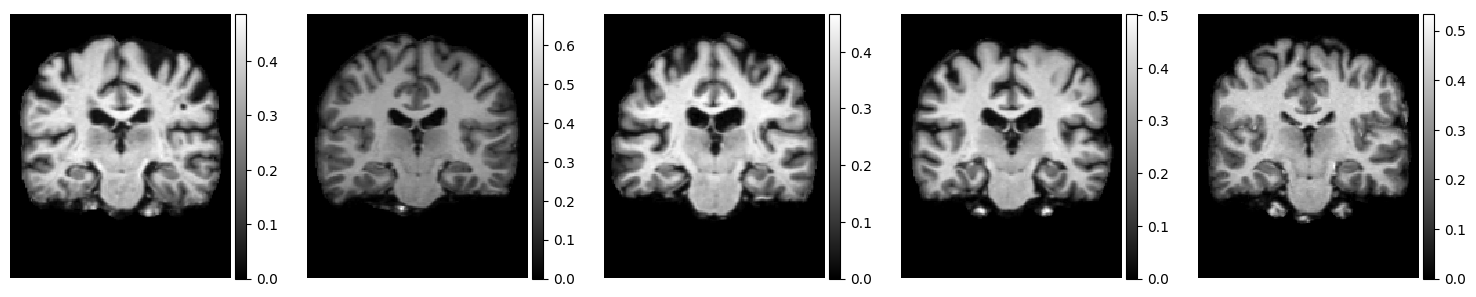

In [5]:
# extract some brains
nb_vis = 5
idx = np.random.randint(0, x_train.shape[0], [5,])
example_digits = [f for f in x_train[idx, ...]]

# visualize
ne.plot.slices(example_digits, cmaps=['gray'], do_colorbars=True);

In [6]:
# unet
vxm_model = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0)

# losses and loss weights
losses = ['mse', vxm.losses.Grad('l2').loss]
loss_weights = [1, 0.01]

In [7]:
vxm_model.compile(optimizer=tf.keras.optimizers.Adam(lr=1e-4), loss=losses, loss_weights=loss_weights)

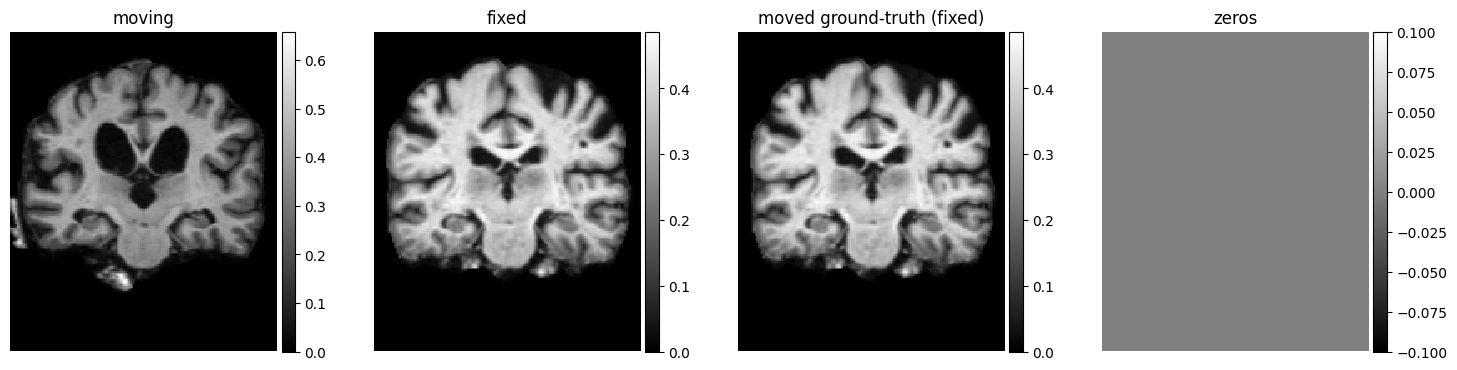

In [8]:
# let's test it
train_generator = vxm_data_generator(x_train, batch_size=8)
in_sample, out_sample = next(train_generator)

# visualize
images = [img[0, :, :, 0] for img in in_sample + out_sample]
titles = ['moving', 'fixed', 'moved ground-truth (fixed)', 'zeros']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);

In [9]:
hist = vxm_model.fit_generator(train_generator, epochs=800, steps_per_epoch=32, verbose=2)

Epoch 1/800


/tmp/ipykernel_28551/2100794168.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  hist = vxm_model.fit_generator(train_generator, epochs=800, steps_per_epoch=32, verbose=2)
I0000 00:00:1761313306.956124   28699 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 - 6s - loss: 0.0068 - vxm_dense_transformer_loss: 0.0068 - vxm_dense_flow_loss: 2.0149e-04 - 6s/epoch - 198ms/step
Epoch 2/800
32/32 - 1s - loss: 0.0053 - vxm_dense_transformer_loss: 0.0050 - vxm_dense_flow_loss: 0.0322 - 1s/epoch - 46ms/step
Epoch 3/800
32/32 - 1s - loss: 0.0037 - vxm_dense_transformer_loss: 0.0031 - vxm_dense_flow_loss: 0.0576 - 1s/epoch - 45ms/step
Epoch 4/800
32/32 - 1s - loss: 0.0033 - vxm_dense_transformer_loss: 0.0027 - vxm_dense_flow_loss: 0.0667 - 1s/epoch - 45ms/step
Epoch 5/800
32/32 - 1s - loss: 0.0028 - vxm_dense_transformer_loss: 0.0021 - vxm_dense_flow_loss: 0.0665 - 1s/epoch - 45ms/step
Epoch 6/800
32/32 - 1s - loss: 0.0031 - vxm_dense_transformer_loss: 0.0024 - vxm_dense_flow_loss: 0.0694 - 1s/epoch - 42ms/step
Epoch 7/800
32/32 - 1s - loss: 0.0028 - vxm_dense_transformer_loss: 0.0021 - vxm_dense_flow_loss: 0.0696 - 1s/epoch - 40ms/step
Epoch 8/800
32/32 - 1s - loss: 0.0026 - vxm_dense_transformer_loss: 0.0019 - vxm_dense_flow_loss: 0.0689 - 1s/e

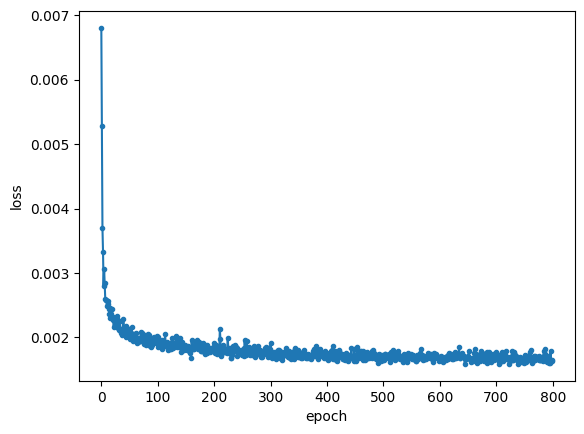

In [10]:
plot_history(hist)

In [11]:
val_generator = vxm_data_generator(x_val, batch_size = 1)
val_input, _ = next(val_generator)

In [12]:
val_pred = vxm_model.predict(val_input)

1/1 [==============================] - 1s 628ms/step


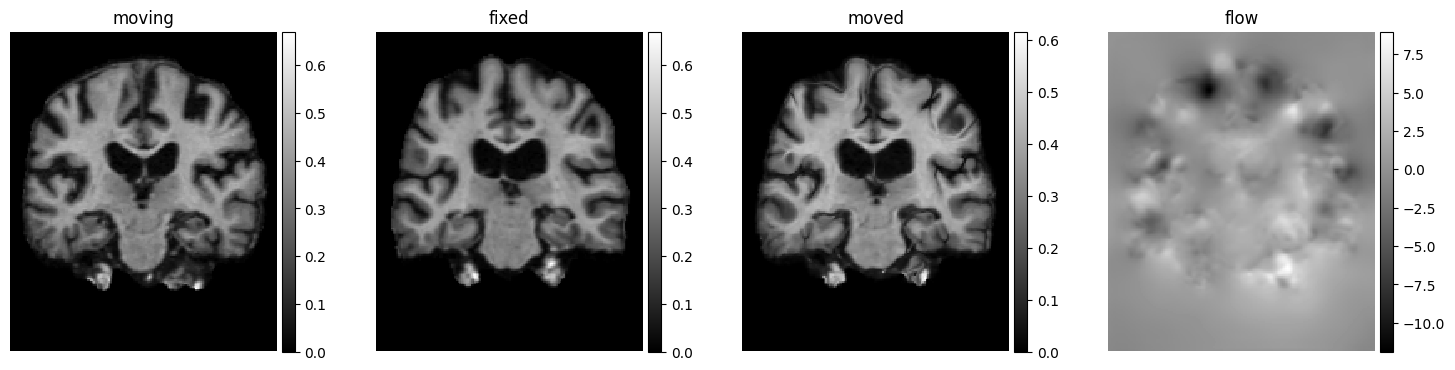

In [13]:
# visualize registration
images = [img[0, :, :, 0] for img in val_input + val_pred]
titles = ['moving', 'fixed', 'moved', 'flow']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);

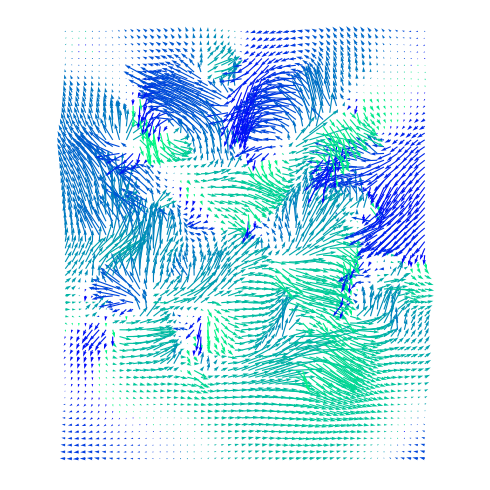

(<Figure size 500x500 with 1 Axes>, [<Axes: >])

In [14]:
flow = val_pred[1].squeeze()[::3,::3]
ne.plot.flow([flow], width=5)

Model: "vxm_dense"
____________________________________________________________________________________________________________________________________________
 Layer (type)                             Output Shape                              Param #       Connected to                              
 vxm_dense_source_input (InputLayer)      [(None, 192, 160, 1)]                     0             []                                        
                                                                                                                                            
 vxm_dense_target_input (InputLayer)      [(None, 192, 160, 1)]                     0             []                                        
                                                                                                                                            
 vxm_dense_unet_input_concat (Concatenat  (None, 192, 160, 2)                       0             ['vxm_dense_source_input[0][0]',     

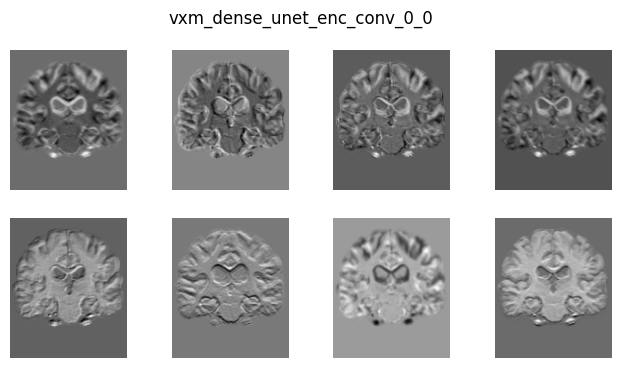

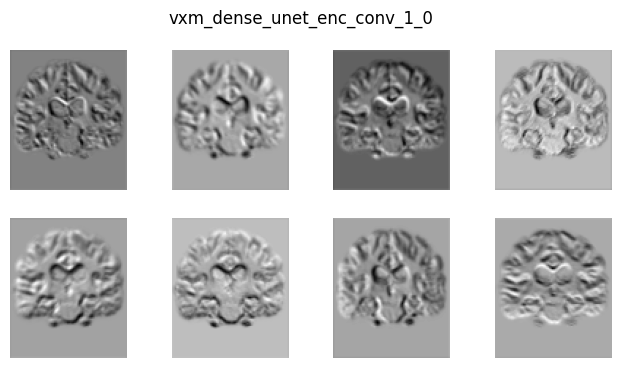

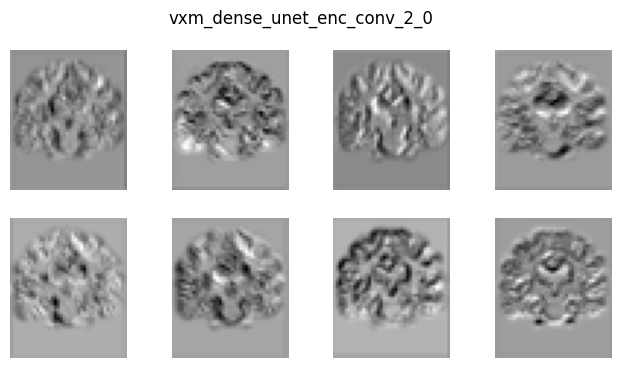

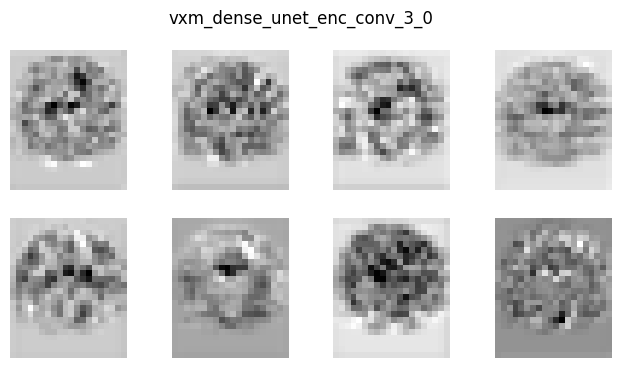

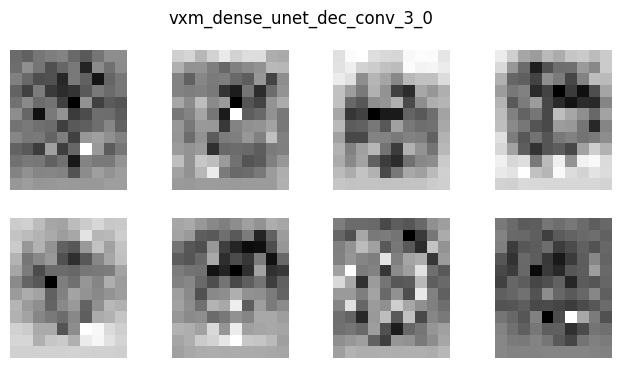

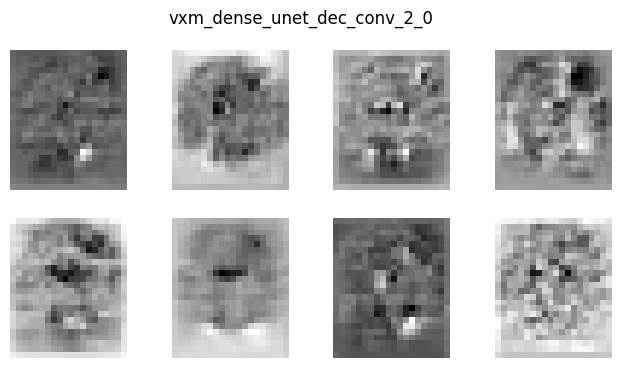

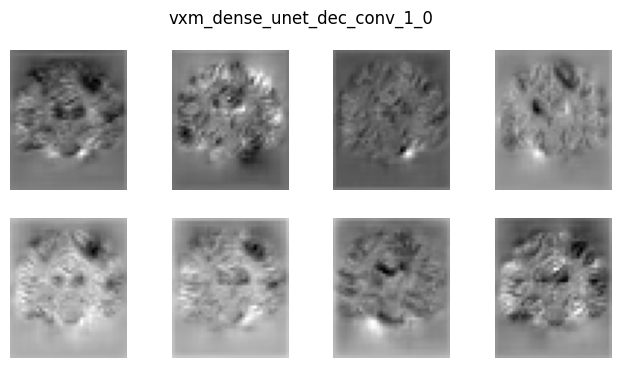

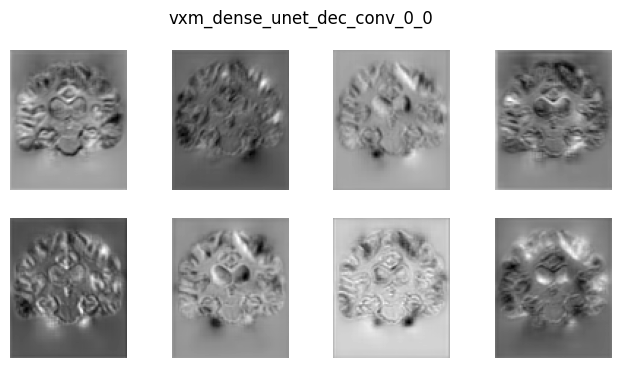

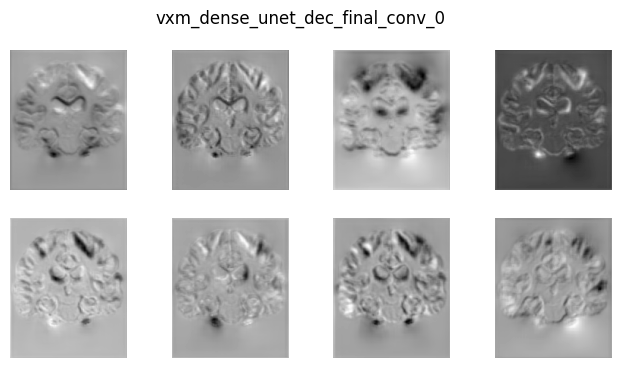

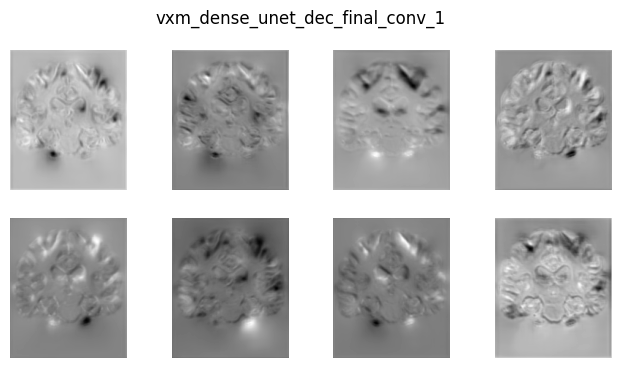

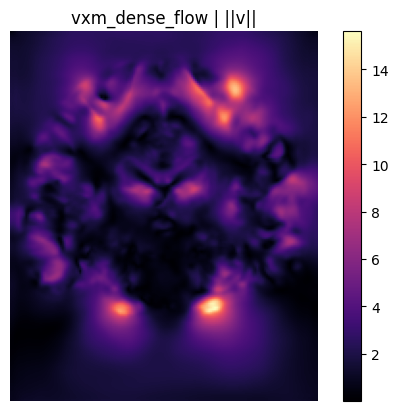

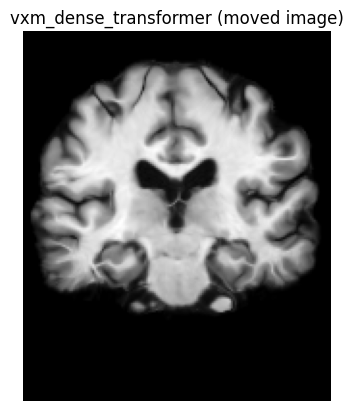

In [16]:
# --- INSPECT + PROBE VoxelMorph (robust) ---

import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1) Print a readable summary and the exact ordered layer list
vxm_model.summary(line_length=140)

print("\n-- Ordered layer dump --")
for i, l in enumerate(vxm_model.layers):
    print(f"{i:03d} | {l.name:40s} | {l.__class__.__name__}")

# 2) Pick useful layers by pattern (matches your printed names)
#    Adjust patterns if you change architectures.
patterns = [
    r'^vxm_dense_unet_enc_conv_\d+_0$',        # encoder convs (pre-activation)
    r'^vxm_dense_unet_dec_conv_\d+_0$',        # decoder convs (pre-activation)
    r'^vxm_dense_unet_dec_final_conv_\d+$',    # final decoder convs
    r'^vxm_dense_flow$',                       # flow field (H, W, 2)
    r'^vxm_dense_transformer$',                # warped/moved image (H, W, 1)
]

# Preserve the model order and deduplicate
selected_names = []
for l in vxm_model.layers:
    if any(re.search(p, l.name) for p in patterns):
        selected_names.append(l.name)

if not selected_names:
    # Fallback: show the names so you can tweak patterns quickly
    print("\n[WARN] No layers matched the probe patterns. Here are a few candidate names:")
    for l in vxm_model.layers:
        if "enc" in l.name or "dec" in l.name or "flow" in l.name or "transformer" in l.name:
            print("  ", l.name)
    raise RuntimeError("Probe selection failed. Adjust `patterns` above to match your printed names.")

print("\n-- Probing these layers (in model order) --")
for n in selected_names:
    print("  ", n)

# 3) Build a probe model safely
probe_outputs = [vxm_model.get_layer(n).output for n in selected_names]
probe_model = tf.keras.Model(inputs=vxm_model.inputs, outputs=probe_outputs)

# 4) Run one batch through and report shapes
sample_in, _ = next(vxm_data_generator(x_train, batch_size=1))
outs = probe_model.predict(sample_in, verbose=0)

print("\n-- Probe output shapes --")
for name, out in zip(selected_names, outs):
    print(f"{name:40s} -> {tuple(out.shape)}")

# 5) Visualization helpers
def show_feature_grid(feat, max_channels=8, title=""):
    """Show up to `max_channels` channels from a [1,H,W,C] tensor."""
    if feat.ndim != 4 or feat.shape[0] != 1:
        return
    c = int(min(feat.shape[-1], max_channels))
    rows = int(np.ceil(c / 4))
    plt.figure(figsize=(8, 2 * rows))
    for i in range(c):
        plt.subplot(rows, 4, i + 1)
        plt.imshow(feat[0, :, :, i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

def show_flow_magnitude(flow, title="flow magnitude"):
    """Visualize ||flow|| for a [1,H,W,2] tensor."""
    if flow.ndim == 4 and flow.shape[-1] == 2:
        mag = np.linalg.norm(flow[0], axis=-1)
        plt.figure()
        plt.imshow(mag, cmap='magma')
        plt.colorbar()
        plt.title(title)
        plt.axis('off')
        plt.show()

# 6) Visualize a few channels for conv layers and flow magnitude
for name, out in zip(selected_names, outs):
    if out.ndim == 4 and out.shape[-1] > 1 and "flow" not in name and "transformer" not in name:
        show_feature_grid(out, max_channels=8, title=name)
    if name.endswith("flow"):
        show_flow_magnitude(out, title=name + " | ||v||")
    if name.endswith("transformer"):
        plt.figure()
        plt.imshow(out[0, :, :, 0], cmap='gray')
        plt.title(name + " (moved image)")
        plt.axis('off')
        plt.show()
